In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
freq = 1295e6
c= 299792458

## Autocorrelation

In [13]:
spectrogram = np.load('/share/nas2/pryder/tumbling_git/exploring_parameters_results/spectrogram_intelsat_128_64.npy')

In [5]:
max_velocity = c / (4 * 19.7e-3* (freq))

#### Checking what the spectrogram looks like

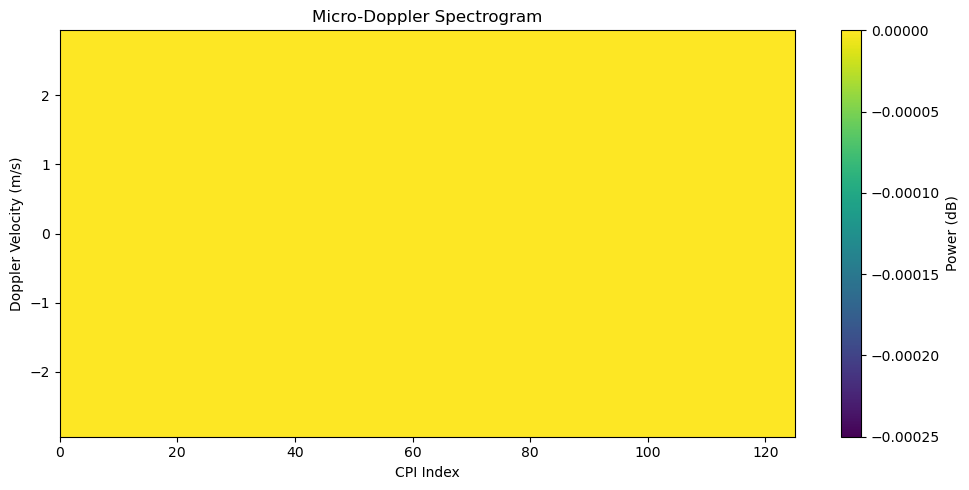

In [19]:
plt.figure(figsize=(10, 5))
plt.imshow(10 * np.log10(spectrogram+1e-12)-np.max(10 * np.log10(spectrogram+1e-12)), aspect='auto', origin='lower', vmin=-0.00025, extent= [0, 125, -max_velocity, max_velocity])
plt.title("Micro-Doppler Spectrogram")
plt.xlabel("CPI Index")
plt.ylabel("Doppler Velocity (m/s)")
plt.colorbar(label='Power (dB)')
plt.tight_layout()

#### Now performing autocorrelation row wise on spectrogram. 

In [ ]:
autocorrelation = np.zeros_like(spectrogram)
for n in range(len(spectrogram.shape[1])):
    row = spectrogram[:, n]
    autocorrelation[:, n] = np.correlate(row, row, mode='full')

autocorrelation = np.sum(autocorrelation, axis=1)

In [ ]:
plt.plot(autocorrelation)
plt.show()